<a href="https://colab.research.google.com/github/Suhangini/Image-Captioning/blob/main/Image_Cap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Device: cpu


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Output dir: /content/captions_out


Saving welding-safety-goggles.jpg to welding-safety-goggles.jpg
Caption: the safety glasses are designed for use with all kinds of glasses


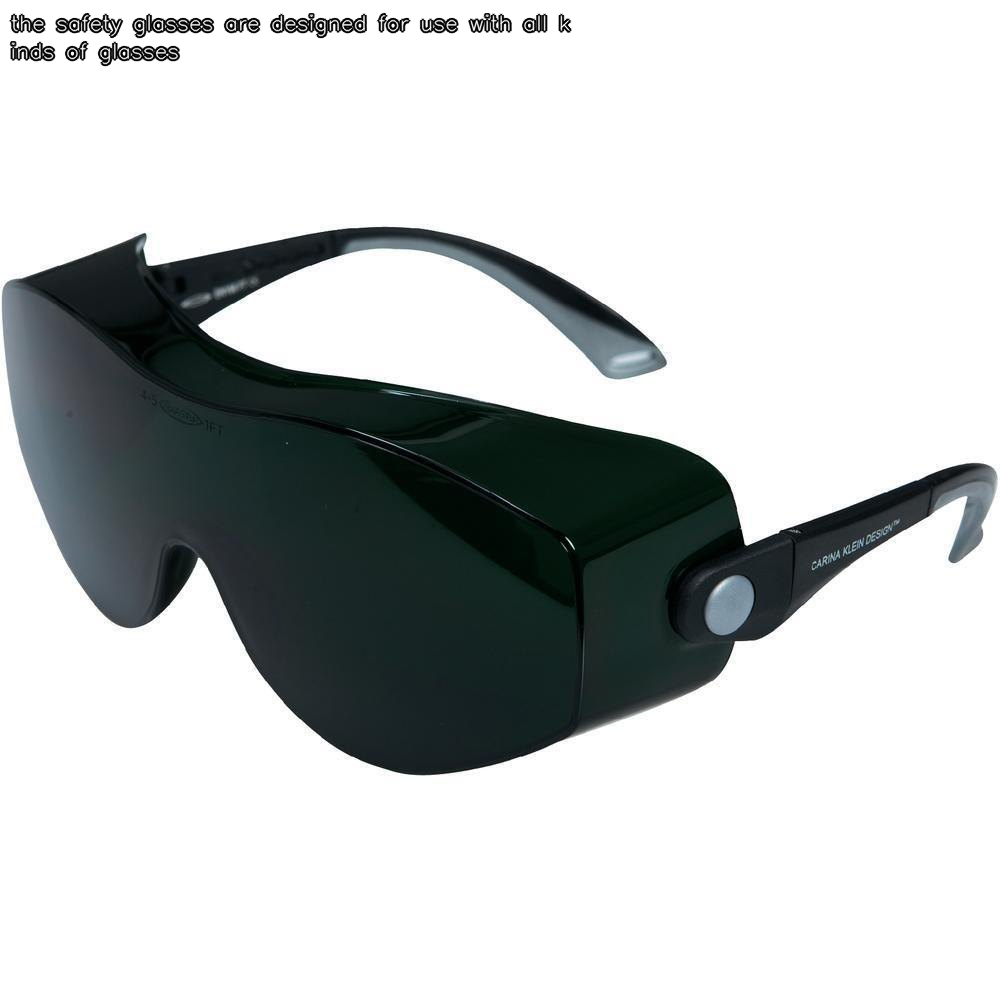

Saved CSV: /content/captions_out/captions.csv


In [ ]:
!pip -q install opencv-python transformers torch torchvision pillow accelerate huggingface-hub
import torch, cv2, os, glob
from PIL import Image
from google.colab import files
from google.colab.patches import cv2_imshow
from transformers import BlipProcessor, BlipForConditionalGeneration

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model_id = "Salesforce/blip-image-captioning-base"
processor = BlipProcessor.from_pretrained(model_id)
model = BlipForConditionalGeneration.from_pretrained(model_id).to(device).eval()

out_dir = "/content/captions_out"
os.makedirs(out_dir, exist_ok=True)
print("Output dir:", out_dir)

# Upload one image
up = files.upload()  # pick one image (jpg/png/webp/bmp)
fname = list(up.keys())[0]

# Read with OpenCV, convert to PIL for BLIP
bgr = cv2.imread(fname)
if bgr is None:
    raise ValueError("Failed to read the uploaded image.")
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
pil_img = Image.fromarray(rgb)

# Generate caption
inputs = processor(images=pil_img, text=None, return_tensors="pt").to(device)
with torch.inference_mode():
    out = model.generate(**inputs, max_new_tokens=30)
caption = processor.decode(out[0], skip_special_tokens=True).strip()

# Save caption and annotated image
base = os.path.basename(fname)
txt_path = os.path.join(out_dir, os.path.splitext(base)[0] + ".txt")
with open(txt_path, "w", encoding="utf-8") as f:
    f.write(caption + "\n")

# Overlay caption
vis = bgr.copy()
y0 = 30
for line in [caption[i:i+50] for i in range(0, len(caption), 50)]:
    cv2.putText(vis, line, (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 3, cv2.LINE_AA)
    cv2.putText(vis, line, (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 1, cv2.LINE_AA)
    y0 += 28

out_img = os.path.join(out_dir, base)
cv2.imwrite(out_img, vis)

print("Caption:", caption)
cv2_imshow(vis)  # works in Colab, imshow() is disabled

# Upload multiple images
ups = files.upload()  # select multiple images

csv_path = os.path.join(out_dir, "captions.csv")
with open(csv_path, "w", encoding="utf-8") as fcsv:
    fcsv.write("filename,caption\n")

    for fname in ups.keys():
        try:
            bgr = cv2.imread(fname)
            if bgr is None:
                print("Skip unreadable:", fname)
                continue
            rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
            pil_img = Image.fromarray(rgb)

            inputs = processor(images=pil_img, text=None, return_tensors="pt").to(device)
            with torch.inference_mode():
                out = model.generate(**inputs, max_new_tokens=30)
            caption = processor.decode(out[0], skip_special_tokens=True).strip()

            # Save text
            base = os.path.basename(fname)
            with open(os.path.join(out_dir, os.path.splitext(base)[0] + ".txt"), "w", encoding="utf-8") as ft:
                ft.write(caption + "\n")

            # Annotate and save image
            vis = bgr.copy()
            y0 = 30
            for line in [caption[i:i+50] for i in range(0, len(caption), 50)]:
                cv2.putText(vis, line, (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,0), 3, cv2.LINE_AA)
                cv2.putText(vis, line, (10, y0), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 1, cv2.LINE_AA)
                y0 += 28

            cv2.imwrite(os.path.join(out_dir, base), vis)

            # Write to CSV
            clean_caption = caption.replace('"', '\\"')
            fcsv.write(f"\"{base}\",\"{clean_caption}\"\n")

            print(base, "->", caption)
        except Exception as e:
            print("Error:", fname, e)

print("Saved CSV:", csv_path)
